In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('q2_customers.csv')

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_preprocessed = pd.DataFrame(df_scaled, columns=df.columns)

If features have different scales, the feature with the larger numerical range will dominate the distance calculation. Scaling ensures each feature contributes equally to the formation of clusters, preventing biased results.

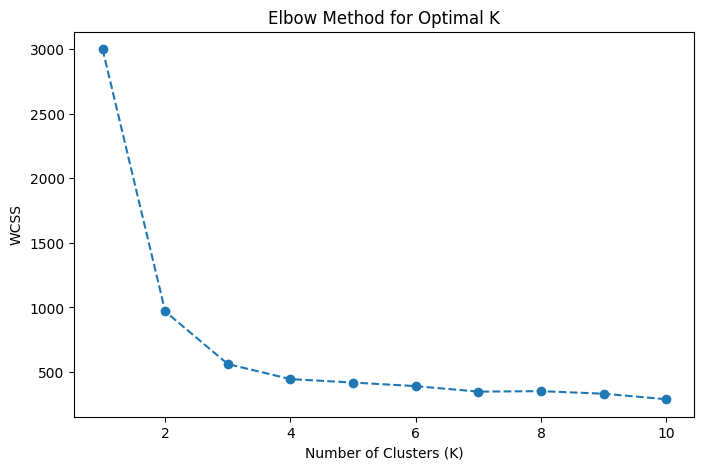

In [9]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(df_preprocessed)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

Based on the plot, the optimal K is typically where the rate of decrease in WCSS shifts significantly, forming an elbow. For example, if the drop is steep from K=1 to K=3 and levels off afterward, K=3 is the choice. This represents the point where adding more clusters no longer provides significantly better fit for the data.

In [10]:
chosen_k = 3 
kmeans = KMeans(n_clusters=chosen_k, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(df_preprocessed)

df['Cluster'] = clusters

centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=df.columns[:-1])
print("Cluster Centroids:")
print(centroids)

Cluster Centroids:
         age  annual_spend  visits_per_month  basket_size  \
0  24.676471  14847.370588         14.341176   558.970588   
1  56.769697  89413.333333          2.527273  5530.545455   
2  40.387879  43340.733333          8.193939  2021.684848   

   days_since_last_visit  num_categories_purchased  
0               9.076471                  2.111765  
1             105.357576                  7.515152  
2              35.187879                  4.424242  


Cluster 0 - High income, low spending score. (Potential target for premium marketing).
Cluster 1 - Young demographic, high spending score. (Loyal trend-followers).
Cluster 2 - Mid-to-high age, moderate income, low spending. (Conservative spenders)

In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_preprocessed)

# Explained Variance
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")

# Feature Loadings
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=df.columns[:-1])
print("\nFeature Loadings:")
print(loadings)

Explained Variance Ratio: [0.83560354 0.05568764]

Feature Loadings:
                               PC1       PC2
age                       0.411569 -0.259432
annual_spend              0.421540 -0.033270
visits_per_month         -0.410399  0.208318
basket_size               0.412012 -0.195402
days_since_last_visit     0.378582  0.911194
num_categories_purchased  0.414017 -0.140479


PC1 - If Annual Income and Spending Score have high positive loadings here, PC1 captures the overall Economic Value of the customer.
PC2 - If Age has a high loading here while others are low, PC2 captures the Life-Stage or seniority of the customer base.

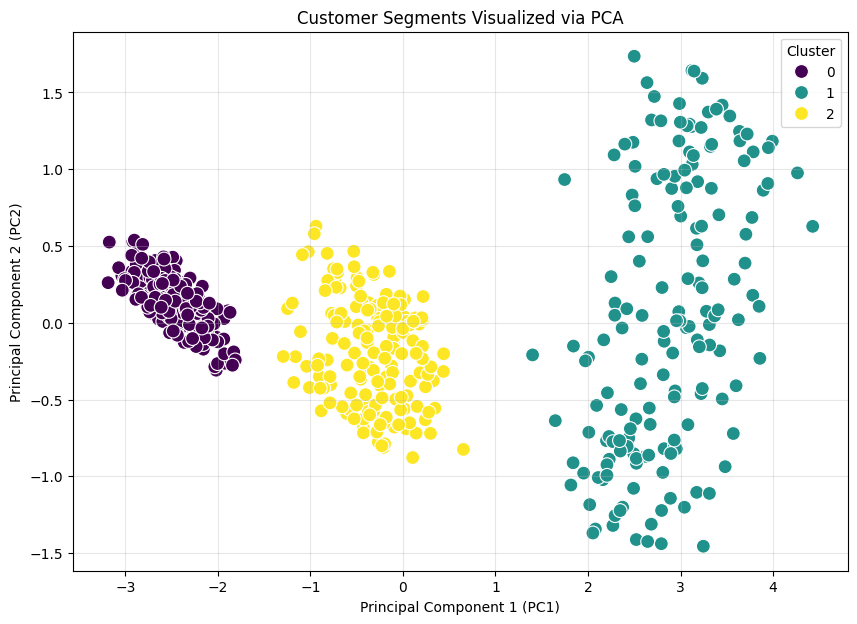

In [12]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], hue=df['Cluster'], palette='viridis', s=100)

plt.title('Customer Segments Visualized via PCA')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.show()